# Multimodal House Price Prediction — Full Pipeline (corrected, v2)
**Dataset:** 52,852 properties (tabular + geo + amenity flags) + 262K listing image URLs.

**Pipeline:** download images (dead links ignored) → chunked frozen DINOv2 embeddings with Drive checkpoints (free-Colab safe) → 5 fusion strategies (concat / early / late / gated GMU / cross-attention) → temporal-split evaluation → modality ablation + imbalance-bias diagnosis → (optional) LLM text features.

**Fixes in this version:** transform/model size mismatch (518 vs 224), corrupt-image fallback shape, resume-safe chunked embedding with checkpoints, NaN imputation with train medians, NaN-loss guard, gradient clipping, `best_state` never None, Colab-friendly workers.

In [ ]:
# Cell 1 — Install dependencies (run once)
# !pip install torch timm pandas numpy scipy requests pillow matplotlib

In [ ]:
# Cell 2 — Imports & configuration
import os, io, csv, json, math
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from PIL import Image
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from torch.utils.data import DataLoader, Dataset, TensorDataset

# ---------------- CONFIG ----------------
PROP_CSV   = "/content/1 - Property_full_Table.csv"
PIC_CSV    = "/content/4 - Picture.csv"
IMG_DIR    = "images"
MAX_IMG    = 10          # photos per property (dataset max)
WORKERS    = 16          # download threads
BATCH      = 512         # training batch size
EPOCHS     = 30
SEEDS      = [0, 1, 2]
MOD_DROPOUT = 0.15       # modality dropout prob during training
HETEROSCEDASTIC = False  # True -> uncertainty-weighted variant
CHUNK      = 20_000      # images per embedding checkpoint
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# Checkpoint dir: Google Drive on Colab (survives disconnects), local otherwise
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = "/content/drive/MyDrive/house_price_ckpt"
except Exception:
    CKPT_DIR = "ckpt"
os.makedirs(CKPT_DIR, exist_ok=True)
print("checkpoints ->", CKPT_DIR)

device: cpu
Mounted at /content/drive
checkpoints -> /content/drive/MyDrive/house_price_ckpt


## Step 1 — Download images (dead links ignored)
Resume-safe: re-running skips files already on disk. Set `SAMPLE = 100` first for a quick liveness probe before committing to all 262K URLs.

In [ ]:
# Cell 3 — Image downloader
SAMPLE = 0   # 0 = everything; 100 = quick liveness probe first

HEADERS_HTTP = {"User-Agent": "Mozilla/5.0 (research; house-price-experiment)"}
MIN_BYTES = 5_000  # smaller = placeholder/error page -> dead

def fetch_one(row):
    pro_id, pic_no, url = row
    fname = f"{pro_id}_{pic_no}.jpg"
    fpath = os.path.join(IMG_DIR, fname)
    if os.path.exists(fpath) and os.path.getsize(fpath) >= MIN_BYTES:
        return (pro_id, pic_no, fname, "cached")
    for _ in range(2):
        try:
            r = requests.get(url, headers=HEADERS_HTTP, timeout=15)
            if r.status_code != 200 or len(r.content) < MIN_BYTES:
                continue
            Image.open(io.BytesIO(r.content)).verify()
            with open(fpath, "wb") as f:
                f.write(r.content)
            return (pro_id, pic_no, fname, "ok")
        except Exception:
            continue
    return (pro_id, pic_no, url, "dead")

os.makedirs(IMG_DIR, exist_ok=True)
pics = pd.read_csv(PIC_CSV)
if SAMPLE > 0:
    pics = pics.sample(SAMPLE, random_state=0)
rows = list(pics[["proID", "picNo", "picAddr"]].itertuples(index=False, name=None))

alive, n_dead = [], 0
with ThreadPoolExecutor(max_workers=WORKERS) as ex, \
     open("dead_links.csv", "w", newline="") as fdead:
    dead_writer = csv.writer(fdead); dead_writer.writerow(["proID", "picNo", "url"])
    futs = [ex.submit(fetch_one, r) for r in rows]
    for i, fut in enumerate(as_completed(futs)):
        pid, pno, name_or_url, status = fut.result()
        if status in ("ok", "cached"):
            alive.append((pid, pno, name_or_url))
        else:
            n_dead += 1; dead_writer.writerow([pid, pno, name_or_url])
        if (i + 1) % 5000 == 0:
            print(f"{i+1}/{len(rows)}  alive={len(alive)}  dead={n_dead}")

manifest = pd.DataFrame(alive, columns=["proID", "picNo", "filename"]).sort_values(["proID", "picNo"])
manifest.to_csv(os.path.join(CKPT_DIR, "image_manifest.csv"), index=False)
print(f"Alive: {len(manifest)}/{len(rows)} | properties with >=1 live image: "
      f"{manifest.proID.nunique()}/{pics.proID.nunique()}")

5000/262179  alive=4937  dead=63
10000/262179  alive=9924  dead=76
15000/262179  alive=14910  dead=90
20000/262179  alive=19875  dead=125
25000/262179  alive=24833  dead=167
30000/262179  alive=29786  dead=214
35000/262179  alive=34726  dead=274
40000/262179  alive=39651  dead=349
45000/262179  alive=44559  dead=441
50000/262179  alive=49444  dead=556
55000/262179  alive=54335  dead=665
60000/262179  alive=59216  dead=784
65000/262179  alive=64006  dead=994
70000/262179  alive=68742  dead=1258
75000/262179  alive=73538  dead=1462
80000/262179  alive=78310  dead=1690
85000/262179  alive=83114  dead=1886
90000/262179  alive=87914  dead=2086
95000/262179  alive=92714  dead=2286
100000/262179  alive=97461  dead=2539
105000/262179  alive=102236  dead=2764
110000/262179  alive=107041  dead=2959
115000/262179  alive=111831  dead=3169
120000/262179  alive=116609  dead=3391
125000/262179  alive=121349  dead=3651
130000/262179  alive=126110  dead=3890
135000/262179  alive=130863  dead=4137
14000

## Step 2 — Chunked DINOv2 embeddings (resume-safe, free-Colab friendly)
Fixes applied: model forced to 224 **and** transform config forced to 224 (they disagreed before → the `Input height (518)` error); corrupt-image fallback matches `IN_SIZE`; `num_workers=2`; memory-mapped output + per-chunk checkpoints on Drive → a disconnect costs one chunk, not the whole run.

In [ ]:
# Cell 4 — Chunked embedding extraction with resume
import timm

manifest = pd.read_csv(os.path.join(CKPT_DIR, "image_manifest.csv"))
backbone = timm.create_model("vit_small_patch14_dinov2.lvd142m",
                             pretrained=True, num_classes=0,
                             img_size=224).to(DEVICE).eval()
cfg = timm.data.resolve_data_config({}, model=backbone)
cfg["input_size"] = (3, 224, 224)      # FIX: transform must match resized model
transform = timm.data.create_transform(**cfg)
IN_SIZE = cfg["input_size"]

# sanity check before the long run
_x = transform(Image.new("RGB", (500, 400)))
assert tuple(_x.shape) == IN_SIZE, _x.shape
with torch.no_grad():
    assert backbone(_x[None].to(DEVICE)).shape[1] == backbone.num_features
print("shape sanity check OK:", _x.shape)

class ImgDataset(Dataset):
    def __init__(self, mf): self.rows = mf.reset_index(drop=True)
    def __len__(self): return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.iloc[i]
        try:
            img = Image.open(os.path.join(IMG_DIR, r.filename)).convert("RGB")
            return transform(img), i
        except Exception:
            return torch.zeros(*IN_SIZE), -i - 1   # FIX: matches transform shape

D = backbone.num_features
N = len(manifest)
emb_path  = os.path.join(CKPT_DIR, "img_emb.npy")
done_path = os.path.join(CKPT_DIR, "chunks_done.json")
bad_path  = os.path.join(CKPT_DIR, "bad_rows.json")

if os.path.exists(emb_path):
    embs = np.lib.format.open_memmap(emb_path, mode="r+")
    assert embs.shape == (N, D), "manifest changed -- delete old checkpoint files"
else:
    embs = np.lib.format.open_memmap(emb_path, mode="w+", dtype=np.float32, shape=(N, D))

done = set(json.load(open(done_path))) if os.path.exists(done_path) else set()
bad  = set(json.load(open(bad_path)))  if os.path.exists(bad_path)  else set()

n_chunks = math.ceil(N / CHUNK)
print(f"{N} images, {n_chunks} chunks of {CHUNK}, {len(done)} already done")

for c in range(n_chunks):
    if c in done:
        continue
    lo, hi = c * CHUNK, min((c + 1) * CHUNK, N)
    dl = DataLoader(ImgDataset(manifest.iloc[lo:hi]), batch_size=128,
                    num_workers=2, pin_memory=True)   # FIX: 2 workers for Colab
    with torch.no_grad():
        for x, idx in dl:
            out = backbone(x.to(DEVICE)).cpu().numpy()
            for j, i_local in enumerate(idx.tolist()):
                if i_local < 0:
                    bad.add(lo + (-i_local - 1))
                else:
                    embs[lo + i_local] = out[j]
    embs.flush()
    done.add(c)
    json.dump(sorted(done), open(done_path, "w"))
    json.dump(sorted(bad), open(bad_path, "w"))
    print(f"chunk {c+1}/{n_chunks} done (rows {lo}:{hi}, corrupt so far: {len(bad)})")

print(f"ALL DONE. embedded {N - len(bad)} images, {len(bad)} corrupt (masked)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

shape sanity check OK: torch.Size([3, 224, 224])
246392 images, 13 chunks of 20000, 13 already done
ALL DONE. embedded 246392 images, 0 corrupt (masked)


In [ ]:
# Cell 5 — Build per-property padded tensors + masks (saved to checkpoint dir)
manifest = pd.read_csv(os.path.join(CKPT_DIR, "image_manifest.csv"))
embs = np.load(os.path.join(CKPT_DIR, "img_emb.npy"), mmap_mode="r")
bad = set(json.load(open(os.path.join(CKPT_DIR, "bad_rows.json")))) \
      if os.path.exists(os.path.join(CKPT_DIR, "bad_rows.json")) else set()
D = embs.shape[1]

props = pd.read_csv(PROP_CSV)
pro_ids = props["ID"].values
id_to_rows = manifest.reset_index().groupby("proID")["index"].apply(list).to_dict()

X = np.zeros((len(pro_ids), MAX_IMG, D), dtype=np.float32)
M = np.zeros((len(pro_ids), MAX_IMG), dtype=np.float32)
n_img = np.zeros(len(pro_ids), dtype=np.int32)
for p, pid in enumerate(pro_ids):
    rws = [r for r in id_to_rows.get(pid, []) if r not in bad][:MAX_IMG]
    n_img[p] = len(rws)
    for k, r in enumerate(rws):
        X[p, k] = embs[r]; M[p, k] = 1.0

# guard: an all-zero embedding that slipped through counts as dead
zero_emb = (np.abs(X).sum(-1) == 0) & (M == 1)
M[zero_emb] = 0.0
n_img = M.sum(1).astype(np.int32)

np.savez_compressed(os.path.join(CKPT_DIR, "property_images.npz"),
                    emb=X, mask=M, n_img=n_img, proID=pro_ids)
zero = int((n_img == 0).sum())
print(f"saved to {CKPT_DIR}. properties with 0 live images: {zero} "
      f"({100*zero/len(pro_ids):.1f}%) -> mask handles them")

## Step 3 — Model definitions
Identical encoders for every fusion → differences attributable to the fusion mechanism alone.

| fusion | mechanism |
|---|---|
| `concat` | naive concatenation (criticized baseline) |
| `early` | shared-dim projection → concat → joint MLP |
| `late` | per-modality regressors + learned weighted average |
| `gated` | GMU; gate sees features **and** modality-richness metadata (quality-aware) |
| `xattn` | modality tokens + [CLS] transformer (cross-modal multi-head attention) |

In [ ]:
# Cell 6 — Encoders
class MLP(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_hidden, d_hidden), nn.GELU(), nn.Dropout(p),
            nn.Linear(d_hidden, d_out))
    def forward(self, x): return self.net(x)

class TabularEncoder(nn.Module):
    def __init__(self, n_numeric, cat_cardinalities, d_out=128):
        super().__init__()
        self.embs = nn.ModuleList(
            [nn.Embedding(c, min(32, (c + 1) // 2)) for c in cat_cardinalities])
        d_cat = sum(e.embedding_dim for e in self.embs)
        self.mlp = MLP(n_numeric + d_cat, 256, d_out)
    def forward(self, x_num, x_cat):
        cats = [e(x_cat[:, i]) for i, e in enumerate(self.embs)]
        return self.mlp(torch.cat([x_num] + cats, dim=1))

class ImageSetEncoder(nn.Module):
    """Attention pooling over up to MAX_IMG photos.
    Returns pooled vector + per-image attention weights (explainability).
    All-dead-images -> learned no-image token."""
    def __init__(self, d_img, d_out=128):
        super().__init__()
        self.proj = nn.Linear(d_img, d_out)
        self.attn = nn.Sequential(nn.Linear(d_out, d_out), nn.Tanh(), nn.Linear(d_out, 1))
        self.no_image = nn.Parameter(torch.zeros(d_out))
    def forward(self, emb, mask):
        h = self.proj(emb)
        a = self.attn(h).squeeze(-1).masked_fill(mask == 0, -1e9)
        w = torch.softmax(a, dim=1)
        pooled = torch.einsum("bk,bkd->bd", w, h)
        has_img = (mask.sum(1, keepdim=True) > 0).float()
        return has_img * pooled + (1 - has_img) * self.no_image, w

class GeoEncoder(nn.Module):
    """Random Fourier features over (lat,lng) + spatial-temporal comps feature."""
    def __init__(self, n_freq=32, d_out=64, d_extra=1):
        super().__init__()
        self.register_buffer("B", torch.randn(2, n_freq) * 10.0)
        self.mlp = MLP(2 * n_freq + d_extra, 128, d_out)
    def forward(self, latlng, extra):
        proj = latlng @ self.B
        return self.mlp(torch.cat([torch.sin(proj), torch.cos(proj), extra], dim=1))

In [ ]:
# Cell 7 — Fusion modules + FusionModel
class ModalityDropout(nn.Module):
    def __init__(self, p=0.15):
        super().__init__(); self.p = p
    def forward(self, feats):
        if not self.training or self.p == 0: return feats
        return [f * (torch.rand(f.size(0), 1, device=f.device) > self.p).float()
                for f in feats]

class GMU(nn.Module):
    """Gated Multimodal Unit; gate sees features + quality metadata."""
    def __init__(self, dims, d_out, d_meta):
        super().__init__()
        self.h = nn.ModuleList([nn.Sequential(nn.Linear(d, d_out), nn.Tanh()) for d in dims])
        self.gate = nn.Linear(sum(dims) + d_meta, len(dims))
    def forward(self, feats, meta):
        hs = torch.stack([h(f) for h, f in zip(self.h, feats)], dim=1)
        z = torch.softmax(self.gate(torch.cat(feats + [meta], dim=1)), dim=1)
        return torch.einsum("bm,bmd->bd", z, hs), z

class FusionModel(nn.Module):
    MODES = ("concat", "early", "late", "gated", "xattn")
    def __init__(self, d_img_raw, n_numeric, cat_cards, d_text=0,
                 fusion="gated", d=128, heteroscedastic=False, modality_dropout=0.15):
        super().__init__()
        assert fusion in self.MODES
        self.fusion, self.het, self.use_text = fusion, heteroscedastic, d_text > 0
        self.tab = TabularEncoder(n_numeric, cat_cards, d)
        self.img = ImageSetEncoder(d_img_raw, d)
        self.geo = GeoEncoder(d_out=d)
        if self.use_text: self.txt = nn.Linear(d_text, d)
        self.mdrop = ModalityDropout(modality_dropout)

        n_mod = 3 + int(self.use_text)
        d_meta, d_out_head = 2, (2 if heteroscedastic else 1)
        if fusion in ("concat", "early"):
            self.head = MLP(n_mod * d, 256, d_out_head)
        elif fusion == "late":
            self.heads = nn.ModuleList([MLP(d, 128, d_out_head) for _ in range(n_mod)])
            self.w = nn.Linear(n_mod * d + d_meta, n_mod)
        elif fusion == "gated":
            self.gmu = GMU([d] * n_mod, d, d_meta)
            self.head = MLP(d, 128, d_out_head)
        elif fusion == "xattn":
            self.cls = nn.Parameter(torch.zeros(1, 1, d))
            self.mod_emb = nn.Parameter(torch.zeros(1, n_mod, d))
            layer = nn.TransformerEncoderLayer(d, nhead=4, dim_feedforward=4 * d,
                                               batch_first=True, dropout=0.1)
            self.tf = nn.TransformerEncoder(layer, num_layers=2)
            self.head = MLP(d, 128, d_out_head)

    def forward(self, batch):
        f_tab = self.tab(batch["x_num"], batch["x_cat"])
        f_img, img_attn = self.img(batch["img_emb"], batch["img_mask"])
        f_geo = self.geo(batch["latlng"], batch["comps"])
        feats = [f_tab, f_img, f_geo]
        if self.use_text: feats.append(self.txt(batch["txt_emb"]))
        feats = self.mdrop(feats)
        meta, aux = batch["mod_meta"], {"img_attn": img_attn}

        if self.fusion in ("concat", "early"):
            out = self.head(torch.cat(feats, dim=1))
        elif self.fusion == "late":
            preds = torch.stack([h(f) for h, f in zip(self.heads, feats)], 1)
            w = torch.softmax(self.w(torch.cat(feats + [meta], 1)), 1)
            aux["mod_weights"] = w
            out = torch.einsum("bm,bmo->bo", w, preds)
        elif self.fusion == "gated":
            fused, z = self.gmu(feats, meta)
            aux["mod_weights"] = z
            out = self.head(fused)
        else:  # xattn
            toks = torch.stack(feats, dim=1) + self.mod_emb
            toks = torch.cat([self.cls.expand(toks.size(0), -1, -1), toks], 1)
            out = self.head(self.tf(toks)[:, 0])

        if self.het:
            return out[:, 0], out[:, 1], aux
        return out.squeeze(1), None, aux

def gaussian_nll(mu, logvar, y):
    logvar = logvar.clamp(-10, 10)          # FIX: numerical stability
    return (0.5 * (logvar + (y - mu) ** 2 / logvar.exp())).mean()

## Step 4 — Dataset build (NaN-safe)
Fixes: NaNs imputed with **train-set medians** (leak-free), standardized values clipped to ±10, `Lat/Lng` NaNs filled, hard assert that no NaN/Inf survives into `TENSORS` — this is what caused the `train nan val nan` failure.

In [ ]:
# Cell 8 — Spatial-temporal comps + feature build + temporal split
CAT_COLS = ["proType", "agency_name", "Locality", "Postal Code"]
DROP = ["ID", "price", "sold_date", "Lat", "Lng"] + CAT_COLS

def temporal_comps(df, k=10):
    """Median log-price of k nearest spatial neighbours sold strictly earlier."""
    df = df.sort_values("sold_date").reset_index()
    comps = np.full(len(df), np.nan)
    coords = np.nan_to_num(df[["Lat","Lng"]].values, nan=0.5)
    logp, dates = np.log(df["price"].values), df["sold_date"].values
    for t in np.unique(dates):
        prior = dates < t
        cur = np.where(dates == t)[0]
        if prior.sum() < k: continue
        tree = cKDTree(coords[prior])
        _, idx = tree.query(coords[cur], k=k)
        comps[cur] = np.median(logp[np.where(prior)[0][idx]], axis=1)
    return pd.Series(comps, index=df["index"]).sort_index().values

df = pd.read_csv(PROP_CSV)
imgs = np.load(os.path.join(CKPT_DIR, "property_images.npz"))
assert (df["ID"].values == imgs["proID"]).all(), "row order mismatch"

y_all = np.log(df["price"].values.astype(np.float32))
comps = temporal_comps(df).astype(np.float32)
num_cols = [c for c in df.columns if c not in DROP]
x_num = df[num_cols].values.astype(np.float32)
x_cat = np.stack([pd.factorize(df[c])[0] for c in CAT_COLS], 1).astype(np.int64)
x_cat[x_cat < 0] = 0                        # FIX: factorize gives -1 for NaN categories
cat_cards = [int(x_cat[:, i].max()) + 1 for i in range(x_cat.shape[1])]
latlng = np.nan_to_num(df[["Lat", "Lng"]].values.astype(np.float32), nan=0.5)

n_img_arr = imgs["n_img"].astype(np.float32)
txt_len = np.zeros(len(df), np.float32)     # <- plug description word counts here (Cell 13)
mod_meta = np.stack([n_img_arr / MAX_IMG, txt_len], 1)

# temporal split
order = np.argsort(df["sold_date"].values, kind="stable")
n = len(df)
tr, va, te = order[:int(.7*n)], order[int(.7*n):int(.8*n)], order[int(.8*n):]

# FIX: impute NaN with TRAIN median (leak-free), then standardize + clip
x_num = np.where(np.isinf(x_num), np.nan, x_num)
train_med = np.nanmedian(x_num[tr], axis=0)
train_med = np.nan_to_num(train_med, nan=0.0)   # column entirely NaN in train
nan_mask = np.isnan(x_num)
x_num[nan_mask] = np.take(train_med, np.where(nan_mask)[1])
mu_, sd_ = x_num[tr].mean(0), x_num[tr].std(0) + 1e-6
x_num = np.clip((x_num - mu_) / sd_, -10, 10)

comps = np.nan_to_num(comps, nan=np.nanmedian(comps[tr]))
comps = (comps - comps[tr].mean()) / (comps[tr].std() + 1e-6)

TENSORS = dict(
    x_num=torch.tensor(x_num), x_cat=torch.tensor(x_cat),
    latlng=torch.tensor(latlng), comps=torch.tensor(comps[:, None]),
    img_emb=torch.tensor(imgs["emb"]), img_mask=torch.tensor(imgs["mask"]),
    mod_meta=torch.tensor(mod_meta), y=torch.tensor(y_all))
META = dict(cat_cards=cat_cards, d_img=imgs["emb"].shape[2],
            n_numeric=x_num.shape[1], n_img=n_img_arr, d_text=0)

# FIX: hard guarantee -- nothing NaN/Inf enters training
for k, v in TENSORS.items():
    if v.dtype.is_floating_point:
        assert not torch.isnan(v).any(), f"NaN in {k}"
        assert not torch.isinf(v).any(), f"Inf in {k}"
print(f"train {len(tr)} | val {len(va)} | test {len(te)} | "
      f"numeric feats {x_num.shape[1]} | all tensors NaN/Inf-free")

## Step 5 — Train & evaluate all five fusion strategies
Fixes: `best_state` initialized to the model's state (never `None`), immediate error on NaN loss instead of silently training on garbage, gradient clipping.

In [ ]:
# Cell 9 — Train/eval helpers
def make_loader(tensors, idx, shuffle):
    keys = list(tensors.keys())
    ds = TensorDataset(*[tensors[k][idx] for k in keys])
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle), keys

def run_epoch(model, dl, keys, opt=None):
    model.train(opt is not None)
    tot, cnt, preds, ys = 0.0, 0, [], []
    for batch in dl:
        b = {k: v.to(DEVICE) for k, v in zip(keys, batch)}
        y = b.pop("y")
        mu, logvar, _ = model(b)
        loss = gaussian_nll(mu, logvar, y) if logvar is not None \
            else torch.nn.functional.huber_loss(mu, y)
        if opt:
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # FIX
            opt.step()
        tot += loss.item() * len(y); cnt += len(y)
        preds.append(mu.detach().cpu()); ys.append(y.cpu())
    return tot / cnt, torch.cat(preds).numpy(), torch.cat(ys).numpy()

def metrics(pred_log, y_log):
    p, yv = np.exp(pred_log), np.exp(y_log)
    return dict(
        rmse_log=float(np.sqrt(np.mean((pred_log - y_log) ** 2))),
        mae_log=float(np.mean(np.abs(pred_log - y_log))),
        mape=float(np.mean(np.abs(p - yv) / yv) * 100),
        r2=float(1 - np.sum((p - yv) ** 2) / np.sum((yv - yv.mean()) ** 2)))

def train_one(fusion, seed, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = FusionModel(META["d_img"], META["n_numeric"], META["cat_cards"],
                        d_text=META["d_text"], fusion=fusion,
                        heteroscedastic=HETEROSCEDASTIC,
                        modality_dropout=MOD_DROPOUT).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    dl_tr, keys = make_loader(TENSORS, tr, True)
    dl_va, _ = make_loader(TENSORS, va, False)
    dl_te, _ = make_loader(TENSORS, te, False)

    best = np.inf
    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}  # FIX: never None
    patience = 0
    for ep in range(EPOCHS):
        tr_loss, _, _ = run_epoch(model, dl_tr, keys, opt)
        if np.isnan(tr_loss):                                          # FIX: fail loudly
            raise RuntimeError(f"NaN loss in {fusion} -- inspect TENSORS")
        va_loss, _, _ = run_epoch(model, dl_va, keys)
        if va_loss < best - 1e-4:
            best = va_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 5: break
        if verbose:
            print(f"  [{fusion} s{seed}] ep{ep:02d} train {tr_loss:.4f} val {va_loss:.4f}")
    model.load_state_dict(best_state)

    _, pred, yv = run_epoch(model, dl_te, keys)
    res = metrics(pred, yv)

    # ablation: images zeroed at test time
    t2 = {k: (torch.zeros_like(v) if k == "img_mask" else v) for k, v in TENSORS.items()}
    dl_ab, _ = make_loader(t2, te, False)
    _, pred_ab, _ = run_epoch(model, dl_ab, keys)
    res["rmse_log_no_images"] = metrics(pred_ab, yv)["rmse_log"]
    res["delta_no_images"] = res["rmse_log_no_images"] - res["rmse_log"]

    # bias diagnosis: |residual| vs image count
    rho, pval = spearmanr(np.abs(pred - yv), META["n_img"][te])
    res["spearman_absresid_vs_nimg"] = float(rho)
    res["spearman_pval"] = float(pval)
    return res, model

In [ ]:
# Cell 10 — Run the full comparison (all fusions x all seeds)
RESULTS = {}
for fusion in FusionModel.MODES:
    per_seed = []
    for seed in SEEDS:
        r, _m = train_one(fusion, seed)
        per_seed.append(r)
    agg = {k: (float(np.mean([r[k] for r in per_seed])),
               float(np.std([r[k] for r in per_seed]))) for k in per_seed[0]}
    RESULTS[fusion] = {"per_seed": per_seed, "mean_std": agg}
    print(f"\n=== {fusion} (mean ± std over {len(SEEDS)} seeds) ===")
    for k, (m, s) in agg.items():
        print(f"  {k:32s} {m:.4f} ± {s:.4f}")

with open(os.path.join(CKPT_DIR, "results_all_fusions.json"), "w") as fp:
    json.dump(RESULTS, fp, indent=2)

table = pd.DataFrame({f: {k: f"{m:.4f}±{s:.4f}" for k, (m, s) in d["mean_std"].items()}
                      for f, d in RESULTS.items()}).T
table  # main comparison table for the paper

  [concat s0] ep00 train 3.5482 val 0.1797
  [concat s0] ep01 train 0.5842 val 0.0508
  [concat s0] ep02 train 0.4344 val 0.0562
  [concat s0] ep03 train 0.3550 val 0.0429
  [concat s0] ep04 train 0.2679 val 0.0412
  [concat s0] ep05 train 0.2327 val 0.0382
  [concat s0] ep06 train 0.2049 val 0.0759
  [concat s0] ep07 train 0.1752 val 0.0248
  [concat s0] ep08 train 0.1542 val 0.0274
  [concat s0] ep09 train 0.1366 val 0.0220
  [concat s0] ep10 train 0.1264 val 0.0249
  [concat s0] ep11 train 0.1193 val 0.0211
  [concat s0] ep12 train 0.1147 val 0.0216
  [concat s0] ep13 train 0.1125 val 0.0217
  [concat s0] ep14 train 0.1120 val 0.0263
  [concat s0] ep15 train 0.1108 val 0.0197
  [concat s0] ep16 train 0.1080 val 0.0392
  [concat s0] ep17 train 0.1070 val 0.0232
  [concat s0] ep18 train 0.1068 val 0.0216
  [concat s0] ep19 train 0.1064 val 0.0240
  [concat s1] ep00 train 3.5112 val 0.1804
  [concat s1] ep01 train 0.5807 val 0.0687
  [concat s1] ep02 train 0.3956 val 0.0533
  [concat s

,rmse_log,mae_log,mape,r2,rmse_log_no_images,delta_no_images,spearman_absresid_vs_nimg,spearman_pval
concat,0.2350±0.0288,0.1693±0.0214,16.3827±1.7890,0.6710±0.0643,0.2745±0.0319,0.0395±0.0186,-0.0638±0.0082,0.0000±0.0000
early,0.2350±0.0288,0.1693±0.0214,16.3827±1.7890,0.6710±0.0643,0.2745±0.0319,0.0395±0.0186,-0.0638±0.0082,0.0000±0.0000
late,0.2445±0.0162,0.1763±0.0135,16.6431±1.1746,0.6229±0.0490,0.2774±0.0078,0.0329±0.0206,-0.0847±0.0262,0.0000±0.0000
gated,0.2702±0.0688,0.2033±0.0597,20.8851±7.8377,0.5846±0.1398,0.2884±0.0618,0.0182±0.0077,-0.0123±0.0274,0.0030±0.0025
xattn,0.2234±0.0092,0.1635±0.0065,15.8839±0.2917,0.6781±0.0398,0.2548±0.0067,0.0314±0.0026,-0.0485±0.0109,0.0002±0.0003


## Step 6 — Explainability & bias analysis

In [ ]:
# Cell 11 — Per-sample modality weights + which-photo attention (gated model)
_, gated_model = train_one("gated", SEEDS[0], verbose=False)
gated_model.eval()
dl_te, keys = make_loader(TENSORS, te, False)
mod_ws, img_ats = [], []
with torch.no_grad():
    for batch in dl_te:
        b = {k: v.to(DEVICE) for k, v in zip(keys, batch)}; b.pop("y")
        _, _, aux = gated_model(b)
        mod_ws.append(aux["mod_weights"].cpu()); img_ats.append(aux["img_attn"].cpu())
mod_ws = torch.cat(mod_ws).numpy()   # [n_test, 3] tabular/image/geo
img_ats = torch.cat(img_ats).numpy() # [n_test, MAX_IMG]

mod_names = ["tabular", "image", "geo"]
print("mean modality weight on test set:",
      dict(zip(mod_names, mod_ws.mean(0).round(3))))

few = META["n_img"][te] <= 2; many = META["n_img"][te] >= 8
print(f"image-modality weight | few photos (<=2): {mod_ws[few,1].mean():.3f}"
      f" | many photos (>=8): {mod_ws[many,1].mean():.3f}")

mean modality weight on test set: {'tabular': np.float32(0.764), 'image': np.float32(0.236), 'geo': np.float32(0.0)}
image-modality weight | few photos (<=2): 0.068 | many photos (>=8): 0.275


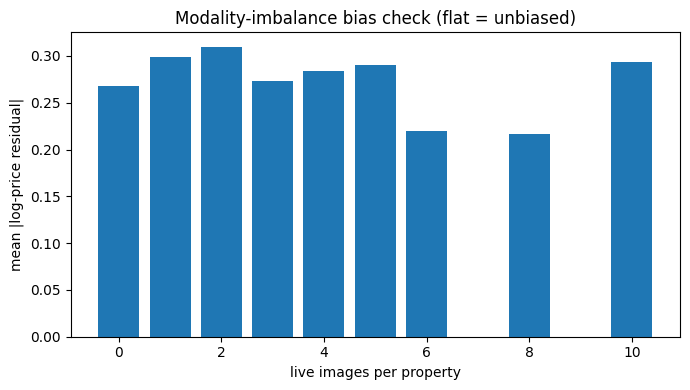

           mean  count
n_img                 
0.0    0.267435    270
1.0    0.299043    418
2.0    0.309679    219
3.0    0.273039   1487
4.0    0.284255   1024
5.0    0.290666   7075
6.0    0.219916     17
8.0    0.216602     10
10.0   0.293135     51


In [ ]:
# Cell 12 — Bias figure: |residual| vs number of live images
import matplotlib.pyplot as plt

_, pred, yv = run_epoch(gated_model, dl_te, keys)
resid = np.abs(pred - yv)
nimg_te = META["n_img"][te]

bins = pd.DataFrame({"n_img": nimg_te, "abs_resid": resid}) \
         .groupby("n_img")["abs_resid"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bins.index, bins["mean"])
ax.set_xlabel("live images per property"); ax.set_ylabel("mean |log-price residual|")
ax.set_title("Modality-imbalance bias check (flat = unbiased)")
plt.tight_layout(); plt.savefig(os.path.join(CKPT_DIR, "bias_nimages.png"), dpi=150)
plt.show()
print(bins)

## Step 7 (optional) — LLM structured text features
Needs the raw description table. Extracted features join the tabular branch (SHAP-explainable); word counts replace the zeros in `mod_meta[:,1]` so the quality-aware gate also sees text richness. Validate on ~200 hand-labelled descriptions.

In [ ]:
# Cell 13 — LLM extraction template (plug in your LLM call)
SCHEMA = {
    "has_kitchen_mention": "Y/N",
    "kitchen_renovated": "Y/N/Unknown",
    "overall_condition": "1-5 ordinal (1=needs work, 5=immaculate)",
    "recently_renovated": "Y/N/Unknown",
    "view_quality": "0-3 (0=none, 3=premium water/city view)",
    "outdoor_space": "Y/N",
    "negations": "list of amenities explicitly stated ABSENT (e.g. 'no parking')",
    "marketing_hype": "1-5 promotional tone",
}
PROMPT = ("You extract structured facts from a real-estate listing description.\n"
          "Answer ONLY with a JSON object matching this schema (no prose):\n{schema}\n"
          "Rules: 'Unknown' when unstated; be conservative; catch negations.\n"
          'Description:\n"""{description}"""')

def ask_llm(prompt: str) -> str:
    raise NotImplementedError("plug in Anthropic API / local LLM here")

def extract_text_features(desc_csv, text_col="description", id_col="proID"):
    ddf = pd.read_csv(desc_csv)
    out = []
    for _, r in ddf.iterrows():
        text = str(r[text_col])[:4000]
        try:
            ans = json.loads(ask_llm(PROMPT.format(
                schema=json.dumps(SCHEMA), description=text)))
        except Exception:
            ans = {}
        ans[id_col] = r[id_col]; ans["desc_word_count"] = len(text.split())
        out.append(ans)
    feats = pd.DataFrame(out)
    for c in ["has_kitchen_mention", "kitchen_renovated",
              "recently_renovated", "outdoor_space"]:
        if c in feats: feats[c] = feats[c].map({"Y": 1, "N": 0}).fillna(-1)
    feats.to_csv("llm_text_features.csv", index=False)
    return feats

# feats = extract_text_features("2_-_Description.csv")
# then: merge into x_num (Cell 8), set txt_len = word counts, rebuild TENSORS, rerun Cell 10

## Evaluation protocol summary (paper-ready)
- Target: **log(price)**; temporal 70/10/20 split by `sold_date` (no market-trend leakage)
- Metrics: RMSE/MAE on log-price, MAPE & R² on price; mean ± std over 3 seeds
- Evidence per research question: fusion comparison table (Cell 10) · `delta_no_images` ablation (modality relevance) · Spearman + bias figure (Cell 12) · gate weights + image attention (Cell 11) · LLM features (Cell 13)

**Resume after a Colab disconnect:** rerun Cells 2 → 4 → 5 → 8 (all fast once checkpoints exist on Drive; Cell 3 only if images aren't downloaded), then continue from wherever you were.